# Feature Engineering

## What is feature Engineering

Using domain knowledge to extract features from raw data. These features can further be used to improve the performance of ML algorithms.

## Why do we do feature engineering

### 1. Improving Model Performance

- This is the most direct reason. By reshaping data, you help the model "see" patterns that it wouldn't be able to detect on its own

- Capturing Non-linear Relationships: A linear model can't understand a curve.3 If you have a feature like $x$, but the relationship is $x^2$, creating a new feature $x^2$ allows the model to capture that relationship.

- Creating Interactions: Sometimes two variables only mean something when combined.4 For example, in real estate, "Square Footage" and "Price" are okay, but "Price per Square Foot" is often a much stronger signal for the model.

### 2. Making Data Digestible for Algorithms

- Many algorithms have strict requirements for the data they ingest.

- Numerical Transformation: Most models (like Neural Networks or SVMs) cannot process text or categories like "Red" or "Blue."6 We use One-Hot Encoding or Embeddings to turn these into numbers.

- Scaling: If one feature is "Age" (0–100) and another is "Annual Salary" (0–1,000,000), the model might think salary is 10,000 times more important just because the numbers are bigger. Feature Scaling (Normalization/Standardization) puts them on a level playing field.

### 3. Reducing Complexity and Overfitting

- More data isn't always better. If you have 1,000 features but only 10 are actually useful, the "noise" from the other 990 can confuse the model, leading to overfitting (where the model memorizes the training data but fails in the real world).

- Feature Selection: We remove redundant or irrelevant features to make the model simpler and faster.

- Dimensionality Reduction: Techniques like PCA (Principal Component Analysis) compress many features into a few "super features" that contain most of the original information

### 4. Injecting Human Expertise (Domain Knowledge)

- Algorithms are great at math but have zero "common sense." Feature engineering is how you teach the model what you know about the world.

- Example: If you are predicting house prices, a "Date" column might not be useful. But if you extract "Is it a Weekend?" or "Is it a Holiday?", you’ve given the model a human insight that usually correlates with market activity.

## Types of Feature Engineering

Feature Engineering is divided into 4 types:

- Feature Transformation
  - Missing Value Imputation
  - Handling Categorical Features
  - Outlier Detection
  - Feature Scaling

- Feature Construction
- Feature Selection
- Feature Extraction

## Feature Scaling

### What is Feature Scaling

Feature scaling is a data preprocessing technique used to bring all the numerical variables in a dataset onto a common scale

### Why do we do it?

1. Speeding Up "Gradient Descent"
Many models (like Linear Regression and Neural Networks) use an optimization algorithm called Gradient Descent to find the best solution.

- The Problem: If features have vastly different scales, the "loss landscape" looks like a long, narrow valley. The model will bounce back and forth (oscillate) and take a long time to reach the bottom.
+1

- The Solution: Scaling makes the landscape more "circular" or spherical, allowing the model to take a direct path to the optimal solution much faster.

2. Fairness for Distance-Based Models
Algorithms like K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and K-Means Clustering calculate the "distance" (usually Euclidean) between data points.

- The Problem: If one feature has a range of 0–1,000 and another is 0–1, the distance will be dominated by the 0–1,000 feature. The model effectively ignores the smaller feature.
+1

- The Solution: Scaling ensures that every feature has an equal opportunity to influence the distance calculation.

3. Proper Regularization

- Techniques like Ridge or Lasso Regression add a penalty to the model based on the size of the coefficients (weights).

- If features aren't scaled, the penalty will be applied unfairly. A feature with a tiny scale will naturally have a huge coefficient to compensate, causing the model to penalize it more than a feature with a large scale.

## Standardization

Standardization (also known as Z-score normalization) is a scaling technique that transforms your data so that it has a mean of 0 and a standard deviation of 1.

Mathematically, for every value $x$ in a feature, we calculate the standardized value $z$ using:$$z = \frac{x - \mu}{\sigma}$$Where:

$\mu$ is the mean of the feature.

$\sigma$ is the standard deviation of the feature.

Why Do We Do It?

- Comparability: It allows you to compare features that were originally measured in different units (e.g., comparing "Age" in years to "Income" in dollars).

- Algorithm Requirement: Many algorithms (like Principal Component Analysis, Support Vector Machines, and Logistic Regression) assume that the underlying data is centered around zero and has a similar variance.

- Handling Outliers: Unlike Min-Max scaling, which squishes all data (including outliers) into a tiny range, standardization is more "robust." Outliers will simply end up with a very high or very low Z-score (e.g., +5 or -5), but the rest of the data remains spread out and useful.

When Do We Do It?

- Use it when: Your data follows a Gaussian (Normal) distribution (the classic bell curve).

- Use it when: You are using algorithms that calculate distances (KNN, K-Means) or use Gradient Descent (Neural Networks).

- Skip it when: You are using Tree-based models (Decision Trees, Random Forest, XGBoost). These models are "scale-invariant"—they only care if a value is "greater than X," not how much greater it is.

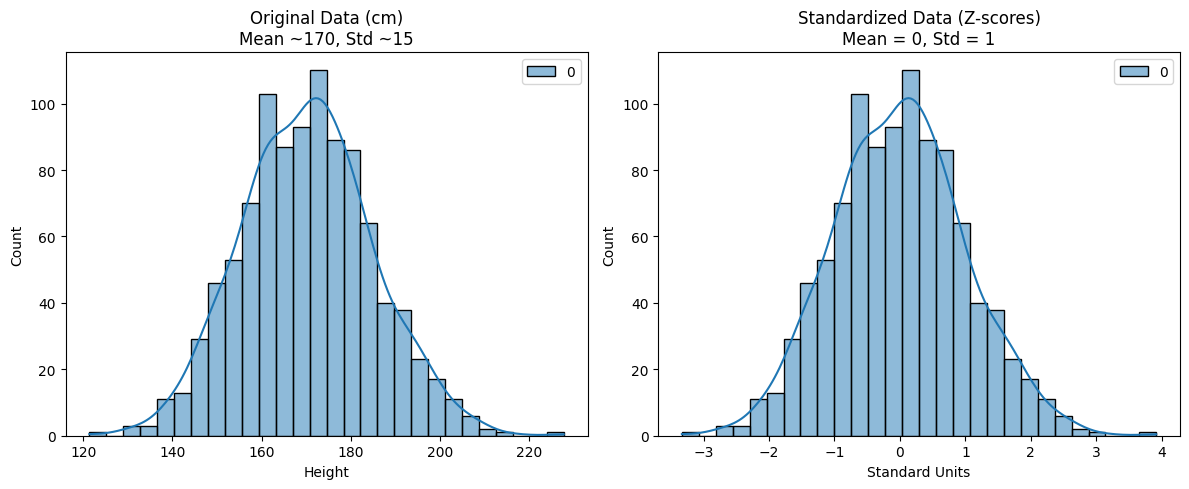

In [1]:
## Sample code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Create dummy data (Height in cm - Mean 170, Std Dev 15)
np.random.seed(42)
heights = np.random.normal(170, 15, 1000).reshape(-1, 1)

# 2. Apply Standardization
scaler = StandardScaler()
standardized_heights = scaler.fit_transform(heights)

# 3. Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Before Scaling
sns.histplot(heights, kde=True, ax=ax1, color='skyblue')
ax1.set_title('Original Data (cm)\nMean ~170, Std ~15')
ax1.set_xlabel('Height')

# After Standardization
sns.histplot(standardized_heights, kde=True, ax=ax2, color='salmon')
ax2.set_title('Standardized Data (Z-scores)\nMean = 0, Std = 1')
ax2.set_xlabel('Standard Units')

plt.tight_layout()
plt.show()